In [5]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

In [ ]:
def ()

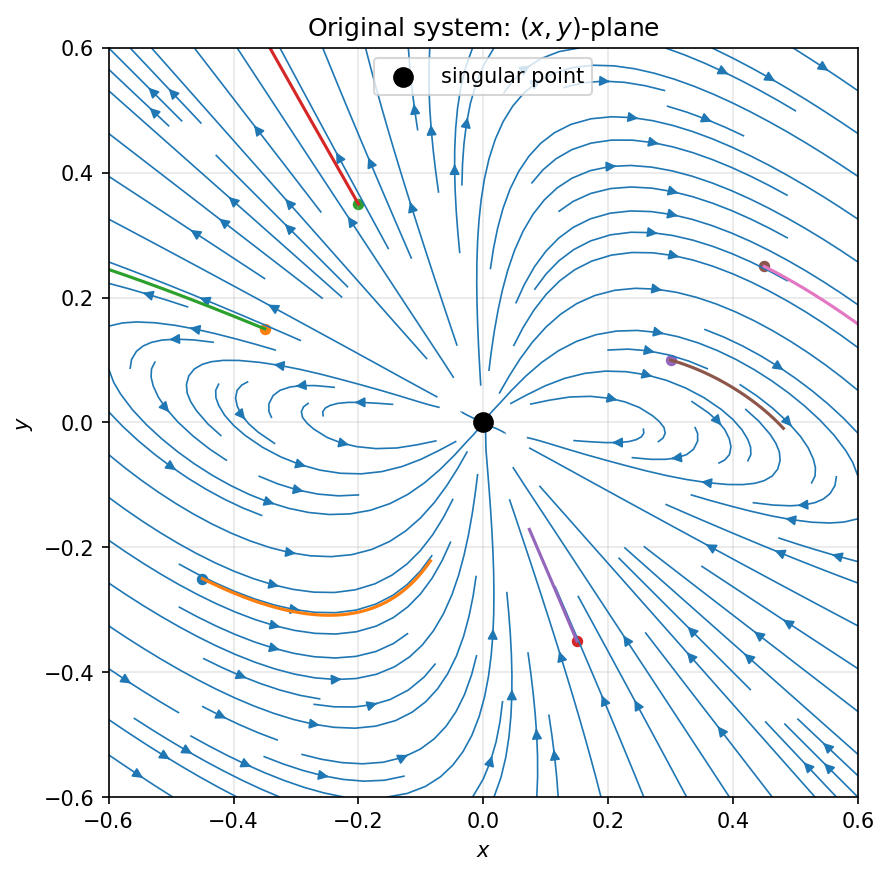

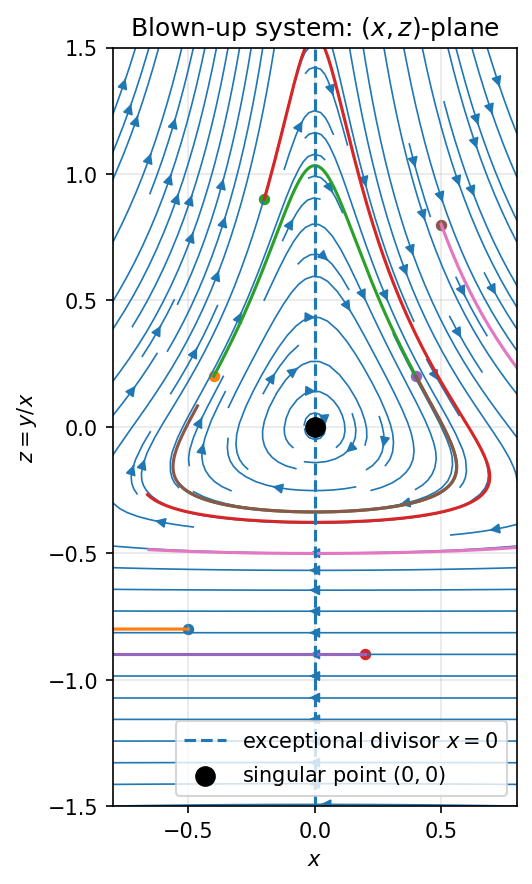

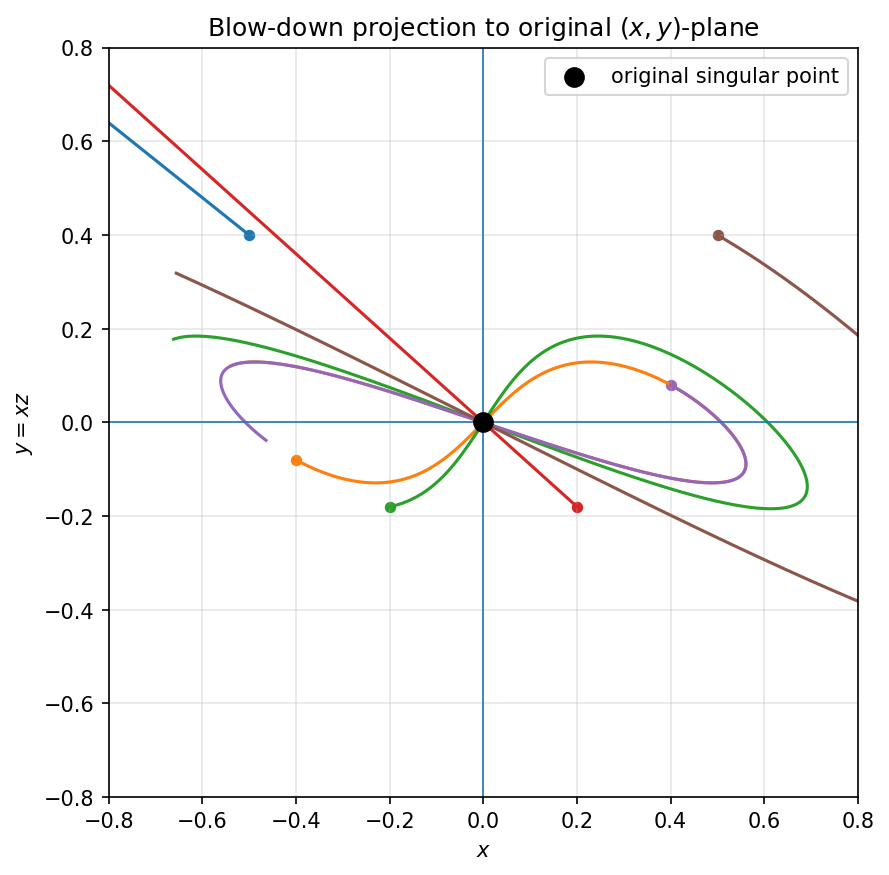

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp


# ============================================================
# Example 2.4 원래 시스템
# dx/dt = xy + (x+y)^4
# dy/dt = y^2 - (x+y)^4
# ============================================================

def original_system(t, state):
    x, y = state

    dx = x * y + (x + y)**4
    dy = y**2 - (x + y)**4

    return [dx, dy]


# ============================================================
# Blow-up 후 시스템
# y = xz
#
# dx/dt = z + x^2(1+z)^4
# dz/dt = -x(1+z)^5
# ============================================================

def blown_up_system(t, state):
    x, z = state

    dx = z + x**2 * (1 + z)**4
    dz = -x * (1 + z)**5

    return [dx, dz]


# ============================================================
# 벡터장 플롯 함수
# ============================================================

def plot_vector_field(ax, system, xlim, ylim, xlabel, ylabel, title):
    x_vals = np.linspace(xlim[0], xlim[1], 35)
    y_vals = np.linspace(ylim[0], ylim[1], 35)

    X, Y = np.meshgrid(x_vals, y_vals)

    U = np.zeros_like(X)
    V = np.zeros_like(Y)

    for i in range(X.shape[0]):
        for j in range(X.shape[1]):
            U[i, j], V[i, j] = system(0, [X[i, j], Y[i, j]])

    speed = np.sqrt(U**2 + V**2)

    # 방향만 보기 위해 정규화
    U_norm = U / (speed + 1e-12)
    V_norm = V / (speed + 1e-12)

    ax.streamplot(
        X, Y,
        U_norm, V_norm,
        density=1.2,
        linewidth=0.8,
        arrowsize=1.0
    )

    ax.set_xlim(xlim)
    ax.set_ylim(ylim)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.grid(True, alpha=0.3)
    ax.set_aspect("equal", adjustable="box")


# ============================================================
# 궤적 추가 함수
# ============================================================

def add_trajectories(ax, system, initial_conditions, t_span, color=None):
    for ic in initial_conditions:
        sol = solve_ivp(
            system,
            t_span,
            ic,
            max_step=0.01,
            rtol=1e-9,
            atol=1e-11
        )

        ax.plot(sol.y[0], sol.y[1], linewidth=1.5, color=color)
        ax.scatter(sol.y[0][0], sol.y[1][0], s=20, color=color)


# ============================================================
# 1. 원래 (x,y)-평면 플롯
# ============================================================

fig, ax = plt.subplots(figsize=(6, 6), dpi=150)

plot_vector_field(
    ax,
    original_system,
    xlim=(-0.6, 0.6),
    ylim=(-0.6, 0.6),
    xlabel=r"$x$",
    ylabel=r"$y$",
    title=r"Original system: $(x,y)$-plane"
)

original_initial_conditions = [
    [-0.45, -0.25],
    [-0.35,  0.15],
    [-0.20,  0.35],
    [ 0.15, -0.35],
    [ 0.30,  0.10],
    [ 0.45,  0.25],
]

add_trajectories(
    ax,
    original_system,
    original_initial_conditions,
    t_span=(0, 3)
)

ax.scatter(0, 0, s=80, color="black", zorder=5, label="singular point")
ax.legend()

plt.tight_layout()
plt.show()


# ============================================================
# 2. Blow-up 후 (x,z)-평면 플롯
# ============================================================

fig, ax = plt.subplots(figsize=(6, 6), dpi=150)

plot_vector_field(
    ax,
    blown_up_system,
    xlim=(-0.8, 0.8),
    ylim=(-1.5, 1.5),
    xlabel=r"$x$",
    ylabel=r"$z=y/x$",
    title=r"Blown-up system: $(x,z)$-plane"
)

blowup_initial_conditions = [
    [-0.50, -0.80],
    [-0.40,  0.20],
    [-0.20,  0.90],
    [ 0.20, -0.90],
    [ 0.40,  0.20],
    [ 0.50,  0.80],
]

add_trajectories(
    ax,
    blown_up_system,
    blowup_initial_conditions,
    t_span=(0, 6)
)

# exceptional divisor x=0
ax.axvline(0, linestyle="--", linewidth=1.5, label=r"exceptional divisor $x=0$")

# blow-up 후 유일한 singular point
ax.scatter(0, 0, s=80, color="black", zorder=5, label=r"singular point $(0,0)$")

ax.legend()

plt.tight_layout()
plt.show()


# ============================================================
# 3. Blow-up 궤적을 원래 평면으로 되돌려서 플롯
#    y = xz
# ============================================================

fig, ax = plt.subplots(figsize=(6, 6), dpi=150)

for ic in blowup_initial_conditions:
    sol = solve_ivp(
        blown_up_system,
        (0, 6),
        ic,
        max_step=0.01,
        rtol=1e-9,
        atol=1e-11
    )

    x = sol.y[0]
    z = sol.y[1]

    # blow-down
    y = x * z

    ax.plot(x, y, linewidth=1.5)
    ax.scatter(x[0], y[0], s=20)

ax.scatter(0, 0, s=80, color="black", zorder=5, label="original singular point")

ax.axhline(0, linewidth=0.8)
ax.axvline(0, linewidth=0.8)

ax.set_xlim(-0.8, 0.8)
ax.set_ylim(-0.8, 0.8)
ax.set_xlabel(r"$x$")
ax.set_ylabel(r"$y=xz$")
ax.set_title(r"Blow-down projection to original $(x,y)$-plane")
ax.grid(True, alpha=0.3)
ax.set_aspect("equal", adjustable="box")
ax.legend()

plt.tight_layout()
plt.show()